# LSTM(Long Short-Term Memory)
- **순환신경망(RNN, Recurrent Neural Network)** 의 한 종류로, 장기 의존성(long-term dependency) 문제를 해결하기 위해 고안된 신경망 구조이다.
- 기존 RNN은 **장기 기억이 어려운 문제(vanishing gradient)** 가 존재
- LSTM은 셀 상태(cell state)와 게이트 구조를 활용하여 장기 의존성을 효과적으로 학습 가능


- 주요 특징장기
    - 기억을 유지할 수 있음
    - 그래디언트 소실(vanishing gradient) 문제 해결
    - 게이트 구조(입력, 출력, 망각 게이트)를 통해 중요한 정보만 유지
    - 자연어 처리(NLP), 시계열 데이터 예측 등에 활용됨

## 1.1.주식 데이터 가져오기
- yfinance에서 데이터를 불러올 때, Ticker(티커)라는 것을 인자로 넣어준다.
- Ticker는 야후 파이낸스 홈페이지에 원하는 종목을 검색하면 Ticker를 볼 수 있다.
- https://finance.yahoo.com/
- Ticker 목록 데이터 : https://www.nasdaq.com/market-activity/stocks/screener?page=1&rows_per_page=25

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
stock = yf.download('035420.KS', start='2022-01-01', end='2026-05-31')
stock = stock.reset_index()

stock.columns = stock.columns.droplevel(1)
stock.tail()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
1068,2026-05-22,203000.0,207000.0,199300.0,201500.0,751620
1069,2026-05-26,200000.0,207000.0,199900.0,205500.0,580181
1070,2026-05-27,198800.0,202000.0,197300.0,199800.0,912403
1071,2026-05-28,205000.0,213000.0,195800.0,202000.0,1978430
1072,2026-05-29,234000.0,247500.0,211000.0,211500.0,7569228


In [3]:
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    1073 non-null   datetime64[s]
 1   Close   1073 non-null   float64      
 2   High    1073 non-null   float64      
 3   Low     1073 non-null   float64      
 4   Open    1073 non-null   float64      
 5   Volume  1073 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 50.4 KB


## 1.2.LSTM으로 주식 예측하기

In [4]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [5]:
# 종가만 사용
close_prices = stock['Close']
close_prices

0       356179.09375
1       345946.84375
2       329867.62500
3       329380.40625
4       326456.87500
            ...     
1068    203000.00000
1069    200000.00000
1070    198800.00000
1071    205000.00000
1072    234000.00000
Name: Close, Length: 1073, dtype: float64

In [7]:
# 데이터 스케일링
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices.values.reshape(-1, 1))

In [8]:
# 시퀀스 데이터 생성
sequence_length = 30
X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i:i+sequence_length])
    y.append(scaled_data[i+sequence_length])

X, y = np.array(X), np.array(y)

In [9]:
# 데이터 분할
# 시간 순서를 유지한 채로 앞 80%는 학습, 뒤 20% 테스트로 나눔.
# 시계열에서는 미래 데이터가 학습에 섞이지 않도록 무작위 분할을 피하는 것이 중요.
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [10]:
# 텐서 변환
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

In [11]:
# 데이터 로더 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


- 모델 정의

In [12]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    # 순전파 연산
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.linear(lstm_out[:,-1,:])

In [13]:
# 정의한 LSTMModel을 실제 모델 객체로 만들고 선택한 device로 이동
model = LSTMModel().to(device)

In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

- 모델 학습

In [ ]:
losses = []

# 모델 학습
model.train()
epochs = 30

for epoch in range(epochs):
    epoch_loss = 0  # 한 epoch 동안의 총 loss 저장
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)       # 손실 계산
        loss.backward()         # 역전파 수행
        optimizer.step()        # 가중치 업데이트
        epoch_loss += loss.item()       # 현재 배치의 손실값을 epoch_loss에 추가

    # 평균 loss
    avg_loss = epoch_loss / len(train_loader)       # 배치 개수로 나누어 평균 손실 계산
    losses.append(avg_loss)

    print(f'Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.4f}')

Epoch 1/30, Loss : 0.1634
Epoch 2/30, Loss : 0.1407
Epoch 3/30, Loss : 0.1193
Epoch 4/30, Loss : 0.1018
Epoch 5/30, Loss : 0.0781
Epoch 6/30, Loss : 0.0602
Epoch 7/30, Loss : 0.0371
Epoch 8/30, Loss : 0.0237
Epoch 9/30, Loss : 0.0195
Epoch 10/30, Loss : 0.0170
Epoch 11/30, Loss : 0.0135
Epoch 12/30, Loss : 0.0100
Epoch 13/30, Loss : 0.0075
Epoch 14/30, Loss : 0.0057
Epoch 15/30, Loss : 0.0053
Epoch 16/30, Loss : 0.0053
Epoch 17/30, Loss : 0.0057
Epoch 18/30, Loss : 0.0056
Epoch 19/30, Loss : 0.0052
Epoch 20/30, Loss : 0.0050
Epoch 21/30, Loss : 0.0050
Epoch 22/30, Loss : 0.0048
Epoch 23/30, Loss : 0.0047
Epoch 24/30, Loss : 0.0047
Epoch 25/30, Loss : 0.0051
Epoch 26/30, Loss : 0.0047
Epoch 27/30, Loss : 0.0046
Epoch 28/30, Loss : 0.0045
Epoch 29/30, Loss : 0.0046
Epoch 30/30, Loss : 0.0044


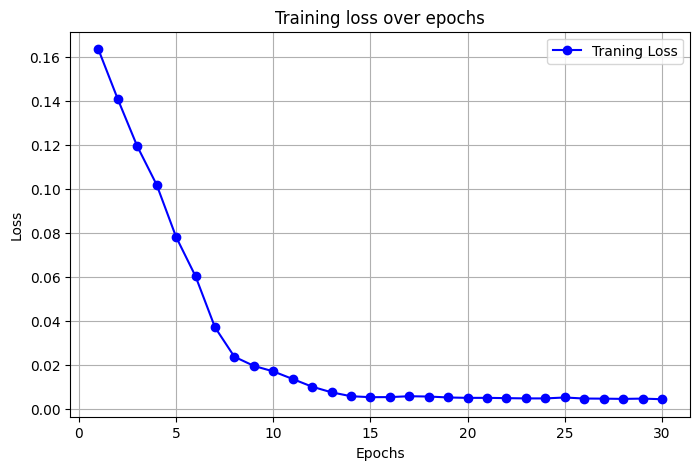

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-', color='b', label='Traning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.legend()
plt.grid()
plt.show()

- 예측 수행

In [18]:
model.eval()                                        # 모델 평가모드로 변경
with torch.no_grad():                               # 그래디언트 계산 비활성화
    predicted = model(X_test_tensor).cpu().numpy()  # 테스트 데이터를 모델에 입력하여 예측 수행

In [19]:
# 예측값 스케일 복원
predicted_prices = scaler.inverse_transform(predicted)
real_prices = scaler.inverse_transform(y_test)

- 결과 시각화

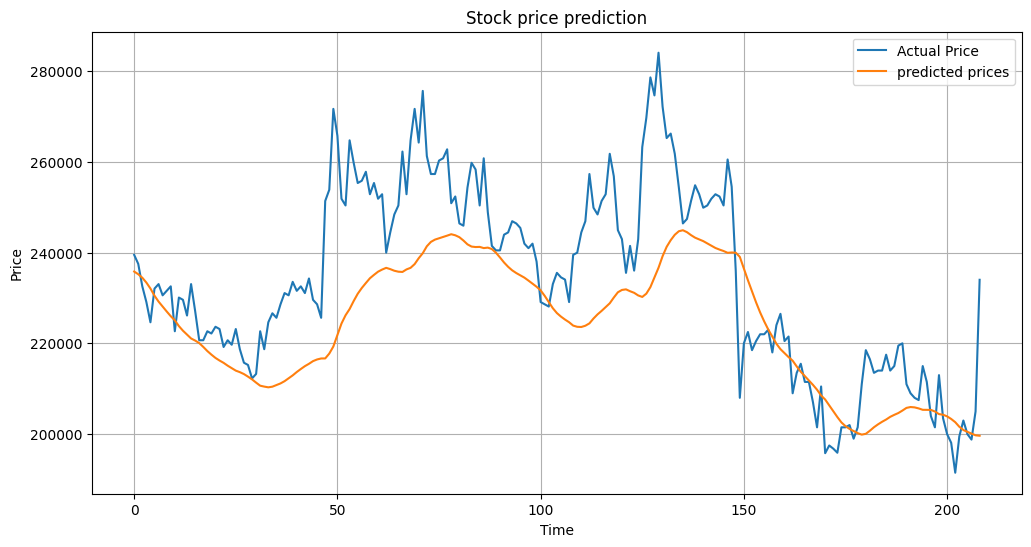

In [20]:
plt.figure(figsize=(12,6))
plt.plot(real_prices, label='Actual Price')
plt.plot(predicted_prices, label='predicted prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock price prediction')
plt.legend()
plt.grid()
plt.show()

- 주식 예측

In [21]:
# 미래 30일 예측을 위해 마지막 테스트 시퀀스를 시작점으로 사용.
future_days = 30

# 마지막 테스트 데이터를 기준으로 시작
recent_sequence = X_test_tensor[-1].cpu().numpy().tolist()

# 하루씩 예측한 값을 순서대로 저장
predictions = []
model.eval()

LSTMModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

In [22]:
# 자기회귀 방식으로 하루 예측하고, 그 예측값을 다시 다음 입력 시퀀스에 붙이고
# 먼 미래로 갈수록 실제 관측값이 아니라 이전 예측값에 의존하므로 오차가 누적될 수 있음.

with torch.no_grad():
    for _ in range(future_days):
        seq_tensor = torch.tensor(recent_sequence[-sequence_length:], dtype=torch.float32).unsqueeze(0).to(device)
        pred = model(seq_tensor).cpu().numpy()
        recent_sequence = np.append(recent_sequence, pred, axis=0)
        predictions.append(pred[0, 0])

# 스케일 역변환
predicted_future_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# 1차원 배열로 변환
predicted_future_prices = predicted_future_prices.flatten()

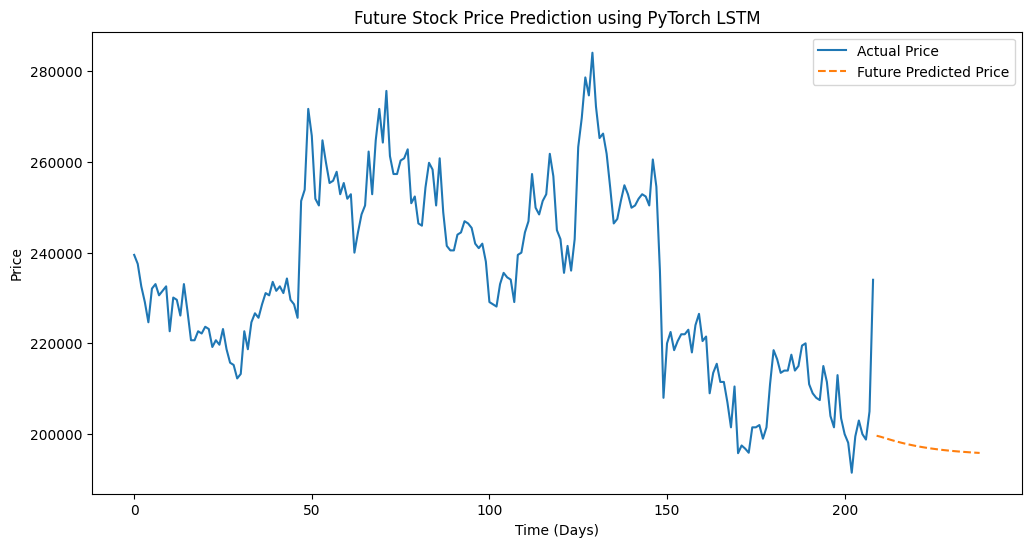

: 

In [ ]:
# 시각화
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Actual Price')

# x축 인덱스 설정
plt.plot(range(len(real_prices), len(real_prices) + future_days),
         predicted_future_prices, label='Future Predicted Price', linestyle='--')

plt.title('Future Stock Price Prediction using PyTorch LSTM')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()